In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

from rdkit import Chem
from rdkit.Chem import Descriptors, Draw, AllChem, DataStructs, Crippen, Lipinski
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

np.random.seed(0)

## 1. Load real bioactivity data — the BACE-1 dataset

**BACE-1** (β-secretase 1) is an enzyme implicated in Alzheimer's disease. This dataset is the canonical single-target QSAR benchmark: ~1,500 small molecules, each with a measured **pIC50** against BACE-1, curated from the literature by MoleculeNet.

- `smiles` — the molecule, as a text string.
- `pIC50` — our regression label. Higher = more potent 

This is exactly the shape of a real lead-optimization dataset: one target, hundreds of molecules clustered into chemical *series*.

In [2]:
URL = "https://raw.githubusercontent.com/illidanlab/MoCL-DK/master/dataset/bace/raw/bace.csv"
df = pd.read_csv(URL)[["mol", "pIC50"]].rename(columns={"mol": "smiles"})

In [3]:
df.head(2)

,smiles,pIC50
0,O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2c...,9.154901
1,Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...,8.853872


In [ ]:
# Convert SMILES to RDKit Mol objects - remove everything that can't be parsed
df["rdmol"] = df["smiles"].apply(Chem.MolFromSmiles)

In [7]:
print(df.shape)
print(f"Number of non-null values in df['rdmol']: {df['rdmol'].notna().sum()}")
print(f"\n{len(df)} compounds | pIC50 range "
      f"{df.pIC50.min():.2f}–{df.pIC50.max():.2f}, mean {df.pIC50.mean():.2f}")

(1513, 3)
Number of non-null values in df['rdmol']: 1513

1513 compounds | pIC50 range 2.54–10.52, mean 6.52


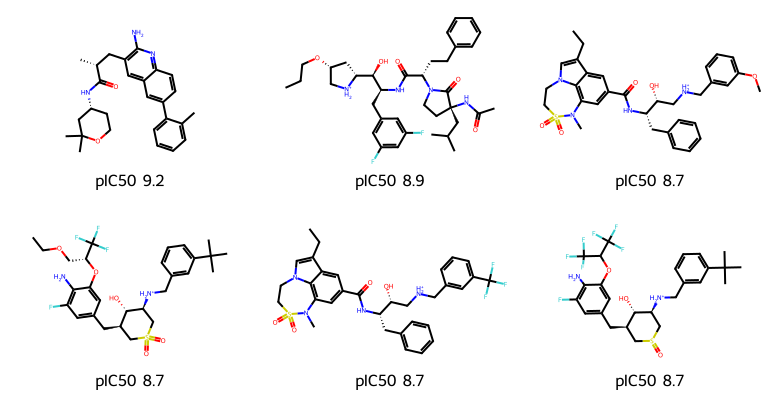

In [8]:
mols = df["rdmol"].iloc[:6].tolist()
legends = [f"pIC50 {v:.1f}" for v in df["pIC50"].iloc[:6]]
Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(260, 200), legends=legends)

## Lipinski

A molecule that binds is useless if it can't behave like a drug. RDKit computes the **Lipinski Rule-of-Five** properties in one line each. Recall the rough thresholds for oral druglikeness:

| Property | Rule-of-Five limit |
|---|---|
| Molecular weight | ≤ 500 |
| LogP (lipophilicity) | ≤ 5 |
| H-bond donors | ≤ 5 |
| H-bond acceptors | ≤ 10 |

These are *guidelines*, not laws — but a model that proposes molecules wildly outside them is proposing things no chemist will make.

In [9]:
df.head(2)

,smiles,pIC50,rdmol
0,O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2c...,9.154901,<rdkit.Chem.rdchem.Mol object at 0x120ec5cb0>
1,Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...,8.853872,<rdkit.Chem.rdchem.Mol object at 0x120ec5d90>


In [10]:
def lipinski_row(rdmol_obj):
    return pd.Series({
        "MW":   Descriptors.MolWt(rdmol_obj),
        "LogP": Crippen.MolLogP(rdmol_obj),
        "HBD":  Lipinski.NumHDonors(rdmol_obj),
        "HBA":  Lipinski.NumHAcceptors(rdmol_obj),
    })

lipinski_props = df["rdmol"].apply(lipinski_row)
df = pd.concat([df, lipinski_props], axis=1)
df.head(2)

,smiles,pIC50,rdmol,MW,LogP,HBD,HBA
0,O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2c...,9.154901,<rdkit.Chem.rdchem.Mol object at 0x120ec5cb0>,431.580,5.04482,2.0,4.0
1,Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...,8.853872,<rdkit.Chem.rdchem.Mol object at 0x120ec5d90>,657.823,2.63860,4.0,5.0


In [11]:
# Check how many compounds conform to Lipinski's rule of 5
is_lipinski = ((df["MW"] <= 500) & (df["LogP"] <= 5) & (df["HBD"] <= 5) & (df["HBA"] <= 10))
print(f"{is_lipinski.sum()} of {len(df)} compounds ({100 * is_lipinski.mean():.1f}%) conform to Lipinski's rule of 5")

860 of 1513 compounds (56.8%) conform to Lipinski's rule of 5


## IC50 ↔ pIC50 by hand — making the label concrete

Label **pIC50** is defined as:

$$\text{pIC50} = -\log_{10}(\text{IC50 in molar})$$

Why train on this instead of raw IC50?
- IC50 spans many orders of magnitude (nanomolar to millimolar) → the log makes it well-distributed for regression.
- The minus sign flips direction so **higher pIC50 = more potent** (intuitive).

Let's back-convert a few pIC50 values into IC50 in nanomolar so the number means something physical. (IC50[M] = 10^(−pIC50); in nM, multiply by 1e9, i.e. IC50[nM] = 10^(9 − pIC50).)

In [23]:
def pic50_to_ic50_nM(pic50):
    '''
    Convert pic50 value to IC50 in nM.
    '''
    return 10 ** (9 - pic50)

for v in [4.0, 6.0, 7.0, 9.0]:
    print(f"pIC50 {v:.1f} -> IC50 {pic50_to_ic50_nM(v):>10,.1f} nM")

print("\nNote: each +1 in pIC50 = 10x tighter binding. "
      "pIC50 9 (≈1 nM) is a drug; pIC50 4 (≈100,000 nM) is barely active.")

# And the forward direction you'd run on raw assay data:
def ic50_nM_to_pic50(ic50_nM):
    return 9 - np.log10(ic50_nM)
print(f"\nRound-trip check: 100 nM -> pIC50 {ic50_nM_to_pic50(100):.2f} -> "
      f"{pic50_to_ic50_nM(ic50_nM_to_pic50(100)):.0f} nM")

pIC50 4.0 -> IC50  100,000.0 nM
pIC50 6.0 -> IC50    1,000.0 nM
pIC50 7.0 -> IC50      100.0 nM
pIC50 9.0 -> IC50        1.0 nM

Note: each +1 in pIC50 = 10x tighter binding. pIC50 9 (≈1 nM) is a drug; pIC50 4 (≈100,000 nM) is barely active.

Round-trip check: 100 nM -> pIC50 7.00 -> 100 nM


> **Trap to remember:** IC50 is *assay-dependent*. Pooling IC50 values measured under different conditions into one training target injects label noise you cannot model away. Real curation means filtering to comparable assays *before* converting to pIC50.

### Featurization: molecules → vectors (Morgan fingerprints)

A Random Forest can't read a graph. The classic QSAR move is the **Morgan / ECFP fingerprint**: a fixed-length bit vector where each bit marks the presence of a local substructure. Here, 2048 bits, radius 2.

In [25]:
def morgan_fingerprint(m, n_bits=2048, radius=2):
    # Calculate Morgan fingerprint as a bit vector
    bv = AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.int8)
    # Convert the bit vector to a numpy array
    DataStructs.ConvertToNumpyArray(bv, arr)
    return arr

X = np.vstack(df["rdmol"].apply(morgan_fingerprint).values)
y = df["pIC50"].values
print(f"Feature matrix X: {X.shape}  ({X.shape[0]} compounds x {X.shape[1]} bits)")
print(f"Labels y:        {y.shape}")

Feature matrix X: (1513, 2048)  (1513 compounds x 2048 bits)
Labels y:        (1513,)


## Bemis–Murcko scaffolds — the source of leakage

Chemists optimize molecules in **series**: they pick a promising core ("scaffold") and decorate it dozens of ways. So a bioactivity dataset is full of near-duplicates that share a scaffold.

The **Bemis–Murcko scaffold** strips a molecule down to its ring systems + linkers, giving the shared core. Let's compute it and see how concentrated the data is.

In [26]:
# Define a function to extract the scaffold from a molecule
def scaffold_of(m):
    # Extract the Murcko scaffold from a molecule and return it as a SMILES string
    return MurckoScaffold.MurckoScaffoldSmiles(mol=m, includeChirality=False)

df["scaffold"] = df["rdmol"].apply(scaffold_of)
n_scaf = df["scaffold"].nunique()
print(f"{len(df)} molecules collapse into just {n_scaf} distinct scaffolds.")

top = df["scaffold"].value_counts().head(5)
print("\nMost common scaffolds (these are tight molecular series):")
for scaf, cnt in top.items():
    print(f"  {cnt:3d} molecules share scaffold:  {scaf[:60]}")

1513 molecules collapse into just 671 distinct scaffolds.

Most common scaffolds (these are tight molecular series):
   55 molecules share scaffold:  O=C1NC=NC1(c1ccccc1)c1ccccc1
   53 molecules share scaffold:  O=S1(=O)CC(Cc2ccccc2)CC([NH2+]Cc2ccccc2)C1
   41 molecules share scaffold:  c1ccc(CCCC[NH2+]C2(c3ccccc3)CCCCC2)cc1
   31 molecules share scaffold:  c1ccc(CCCC[NH2+]C2CC3(CCC3)Oc3ncccc32)cc1
   26 molecules share scaffold:  O=C(NC(CC[NH2+]Cc1ccccc1)Cc1ccccc1)c1ccccc1


This is the whole problem in one statistic: a few hundred scaffolds account for over a thousand molecules. A **random** split scatters members of the same series across train and test — so the model gets tested on molecules nearly identical to ones it trained on. That's not generalization; it's a lookup.

## EXPERIMENT — random split vs. scaffold split

Same features, same model, same test-set *size*. The only thing changed is **how** we split.

In [27]:
def train_and_eval(train_idx, test_idx, label):
    model = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=0)
    model.fit(X[train_idx], y[train_idx])
    pred = model.predict(X[test_idx])
    r2   = r2_score(y[test_idx], pred)
    rmse = np.sqrt(mean_squared_error(y[test_idx], pred))
    print(f"{label:16s}  n_test={len(test_idx):4d}   R2={r2:5.3f}   RMSE={rmse:.3f}")
    return dict(label=label, y_true=y[test_idx], y_pred=pred, r2=r2, rmse=rmse)

# --- (a) RANDOM split: shuffle rows, take last 20% as test ---
rng = np.random.RandomState(42)
perm = rng.permutation(len(df))
cut = int(0.8 * len(df))
res_random = train_and_eval(perm[:cut], perm[cut:], "RANDOM split")

# --- (b) SCAFFOLD split: whole scaffolds go to ONE side only ---
# Fill train with largest scaffolds first until ~80%; the rest (unseen cores) become test.
groups = defaultdict(list)
for i, s in enumerate(df["scaffold"]):
    groups[s].append(i)
ordered = sorted(groups.values(), key=len, reverse=True)

train_idx, test_idx = [], []
for g in ordered:
    if len(train_idx) + len(g) <= 0.8 * len(df):
        train_idx += g
    else:
        test_idx += g
res_scaffold = train_and_eval(np.array(train_idx), np.array(test_idx), "SCAFFOLD split")

drop = res_random["r2"] - res_scaffold["r2"]
print(f"\n>>> R2 dropped by {drop:.2f} ({drop/res_random['r2']*100:.0f}%) "
      f"just by splitting honestly. The random number was measuring memorization.")

RANDOM split      n_test= 303   R2=0.689   RMSE=0.768
SCAFFOLD split    n_test= 303   R2=0.441   RMSE=0.816

>>> R2 dropped by 0.25 (36%) just by splitting honestly. The random number was measuring memorization.


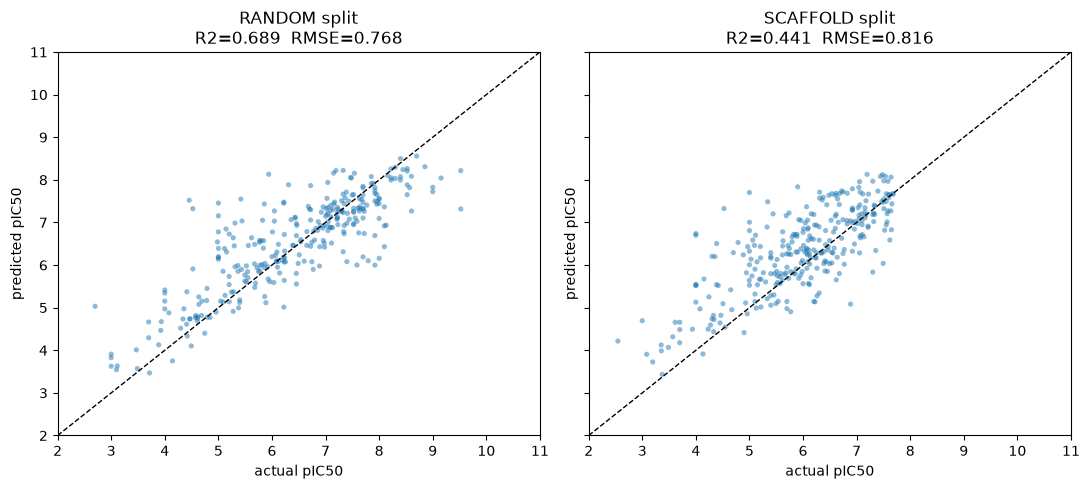

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, res in zip(axes, [res_random, res_scaffold]):
    ax.scatter(res["y_true"], res["y_pred"], s=14, alpha=0.5, edgecolor="none")
    lo, hi = 2, 11
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("actual pIC50"); ax.set_ylabel("predicted pIC50")
    ax.set_title(f"{res['label']}\nR2={res['r2']:.3f}  RMSE={res['rmse']:.3f}")
plt.tight_layout(); plt.show()

*Why* it collapses — a leakage diagnostic

Let's prove the mechanism. For each test molecule, find its **most similar training molecule** (Tanimoto similarity on fingerprints). Under a random split, test molecules have near-twins in training. Under a scaffold split, they don't — and that gap is exactly the performance gap.

Data leakage with scaffold splits refers to a subtle evaluation failure in molecular machine learning where a model appears highly accurate during validation but fails to generalize to truly novel molecules in the real world. [1, 2] 
While a scaffold split is specifically designed to prevent standard data leakage by separating chemicals based on their underlying core structure, it can introduce a false sense of security. The model still manages to "cheat" because molecules with technically different core structures can remain highly similar in their properties and chemical behaviors. [1, 3, 4, 5, 6] 
## The Purpose: Preventing Random Split Leakage
In cheminformatics, molecules often belong to the same chemical series and share identical structural cores (called [Bemis-Murcko scaffolds](http://practicalcheminformatics.blogspot.com/2024/11/some-thoughts-on-splitting-chemical.html)). [5] 

* The Random Split Problem: If you use a traditional random split, highly identical molecules sharing the same core scaffold end up in both the training and test sets. This causes severe group data leakage, where the model merely memorizes the scaffold patterns to pass the test. [2, 7, 8, 9, 10] 
* The Scaffold Split Solution: A scaffold split extracts the core rings and chains of each molecule, placing all variations of a specific scaffold into the same subset (e.g., training only). The test set is strictly populated by entirely "unseen" scaffolds to evaluate Out-of-Distribution (OOD) generalization. [3, 4, 5] 

  Molecules with Same Scaffold
               │
    ┌──────────┴──────────┐
    ▼                     ▼
[ Random Split ]     [ Scaffold Split ]
 ├── Train: Mol A     └── Train: Mol A & Mol B (Kept together)
 └── Test:  Mol B         
 (Causes Leakage)     (Intended to Prevent Leakage)

## The Catch: How "Leakage" Still Occurs
Despite separating identical scaffolds, recent studies demonstrate that scaffold splits frequently overestimate model performance due to hidden structural leaks: [6, 11, 12, 13] 

* The Trivial Substitution Trap: A very minor change to a molecule (such as adding a single atom or switching a carbon to a nitrogen in a ring) completely transforms its structural classification under the Bemis-Murcko logic. The algorithm treats them as completely distinct scaffolds. [1, 5, 14] 
* The Shortcut: Because the core properties, electronic structures, and behaviors of these two molecules remain nearly identical, placing one in the training set and one in the test set creates a functional leak. The model solves the test sample using an easy structural shortcut rather than demonstrating genuine, broad generalization. [1, 2, 4, 15] 
* Inflated Metrics: This hidden overlap means your evaluation metrics (like ROC-AUC or Hit Rates) stay deceptively high during testing. When the model is deployed to screen truly novel, unrelated chemical spaces in active drug discovery, performance plummets. [6, 11, 16] 

## Better Alternatives to Prevent Leakage
To ensure your evaluation is truly representative of real-world discovery, consider moving beyond basic scaffold splits:

* Distance/Clustering Splits: Group molecules using structural fingerprint similarity thresholds (e.g., Butina or UMAP-based clustering) rather than strict ring rules to enforce separation. [3, 6] 
* Temporal Splits: Separate your data chronologically based on when the compounds were synthesized or discovered, mimicking how the model will interact with future data. [6, 17] 
* Optimized Splitting Tools: Use advanced optimization frameworks like [DataSAIL](https://www.nature.com/articles/s41467-025-58606-8), which utilize linear programming to actively minimize structural similarity bounds between the training and test divisions. [18, 19] 




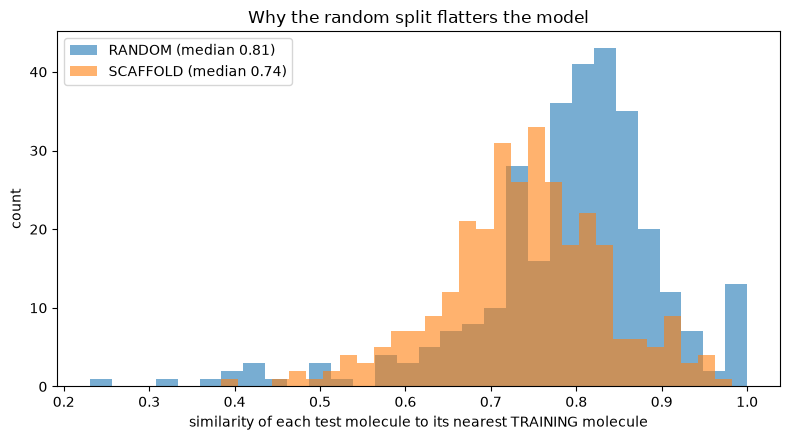

Random-split test molecules sit at median similarity 0.81 to training (near-duplicates).
Scaffold-split test molecules sit at 0.74 — genuinely new chemistry, which is what production looks like.


In [29]:
def max_train_similarity(train_idx, test_idx):
    train_fps = [AllChem.GetMorganFingerprintAsBitVect(df["rdmol"].iloc[i], 2, nBits=2048)
                 for i in train_idx]
    sims = []
    for j in test_idx:
        fp_j = AllChem.GetMorganFingerprintAsBitVect(df["rdmol"].iloc[j], 2, nBits=2048)
        sims.append(max(DataStructs.BulkTanimotoSimilarity(fp_j, train_fps)))
    return np.array(sims)

sim_random   = max_train_similarity(perm[:cut], perm[cut:])
sim_scaffold = max_train_similarity(np.array(train_idx), np.array(test_idx))

plt.figure(figsize=(8, 4.5))
plt.hist(sim_random,   bins=30, alpha=0.6, label=f"RANDOM (median {np.median(sim_random):.2f})")
plt.hist(sim_scaffold, bins=30, alpha=0.6, label=f"SCAFFOLD (median {np.median(sim_scaffold):.2f})")
plt.xlabel("similarity of each test molecule to its nearest TRAINING molecule")
plt.ylabel("count"); plt.legend(); plt.title("Why the random split flatters the model")
plt.tight_layout(); plt.show()

print(f"Random-split test molecules sit at median similarity "
      f"{np.median(sim_random):.2f} to training (near-duplicates).")
print(f"Scaffold-split test molecules sit at {np.median(sim_scaffold):.2f} "
      f"— genuinely new chemistry, which is what production looks like.")

## What to take away

- **Always report the scaffold-split number** for molecular property prediction. If you only have time to internalize one habit from this notebook, it's this.
- The **random-vs-scaffold gap is itself a useful metric** — a large gap means your dataset is highly clustered and your model leans on memorization.
- **pIC50 is a log**: every unit is a 10× change in potency, and the values are assay-dependent before curation.
- The **applicability domain** is real: the nearest-neighbor similarity plot is a cheap way to flag when a prediction is extrapolation rather than interpolation.

### Natural next steps
1. Swap the Random Forest for a **GNN (PyTorch Geometric)** on the molecular graph and re-run the *same* scaffold split — does the GNN close the generalization gap, or just the random-split one?
2. Add an **ADMET task from TDC** and practice multi-objective thinking (potency *and* druglikeness).
3. Hunt for **activity cliffs**: pairs of molecules with high fingerprint similarity but large pIC50 difference — the cases that break similarity-based models and that chemists care about most.